In [29]:
from astropy.table import Table
import numpy as np, matplotlib.pyplot as plt
import time

from gundam import (pccf, proj_cross_counts,
    ProjectedCrossConfig, ProjectedCrossCountsConfig,
    ProjectedBinning, ProjectedGridSpec, ProjectedCatalogColumns,
    WeightSpec, BootstrapSpec, DistanceSpec)

## Read and prepare data

In [19]:
# Read data files and fix types
datafile    = './claudiosample/galaxies.fits'
randomfile  = './claudiosample/rans.fits'
crossfile   = './claudiosample/cross.fits'

data = Table.read(datafile)
rans = Table.read(randomfile)
cross = Table.read(crossfile)
data['Z_NOQSO'] = data['Z_NOQSO'].astype(float)
rans['Z_NOQSO'] = rans['Z_NOQSO'].astype(float)
cross['Z_NOQSO'] = cross['Z_NOQSO'].astype(float)

## Create config and run correlation (unweighted)

In [20]:
cfg1 = ProjectedCrossConfig(
    estimator="DP",        # "NAT", "DP", or "LS"
    columns_data1=ProjectedCatalogColumns(ra="RA", dec="DEC", redshift='Z_NOQSO'),
    columns_data2=ProjectedCatalogColumns(ra="RA", dec="DEC", redshift='Z_NOQSO'),
    columns_random2=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='Z_NOQSO'),
    binning=ProjectedBinning(  # number_rp_bins  minimum_rp  rp_bin_size  number_rv_bins  rv_bin_size
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=1, dsepv=170.0),
    grid=ProjectedGridSpec(
        autogrid=True, pxorder="natural"),
    weights=WeightSpec(
        weight_mode="unweighted"),   # "auto", "weighted", "unweighted"
    bootstrap=BootstrapSpec(
        enabled=True, nbts=50, bseed=12345),
    distance=DistanceSpec(
        calcdist=True, h0=100., omegam=0.25, omegal=0.75),
    nthreads=4,
)

In [21]:
# Estimate correlation
ta = time.time()
res1 = pccf(cross, data, cfg1, random2=rans)
print(f'elapsed time: {time.time()-ta}')

[pccf] preparing data and randoms
[pccf] counting cross terms with estimator=DP


  
  
[pccf] estimating correlation
[pccf] done
elapsed time: 1.1824400424957275


## Create config and run correlation (weighted)

In [40]:
# Put some artifical weights if needed
data['wei'] = 1.0
data['wei'][0:40] = 5.4
data['wei'][900:980] = 5.8
data['wei'][4500:4900] = 8.3
data['wei'][13000:13500] = 6.8
data['wei'][18000:19000] = 4.1
cross['wei'] = 1.0
cross['wei'][5000:6800] = 7.2
cross['wei'][16000:18000] = 3.1

In [41]:
# Create config objects   res = pccf(C, R_of_D, D, R_of_D, cfg_dp)
cfg2 = ProjectedCrossConfig(
    estimator="DP",        # "NAT", "DP", or "LS"
    columns_data1=ProjectedCatalogColumns(ra="RA", dec="DEC", redshift='Z_NOQSO', weight='wei'),
    columns_data2=ProjectedCatalogColumns(ra="RA", dec="DEC", redshift='Z_NOQSO', weight='wei'),
    columns_random2=ProjectedCatalogColumns(ra="ra", dec="dec", redshift='Z_NOQSO'),
    binning=ProjectedBinning(  # number_rp_bins  minimum_rp  rp_bin_size  number_rv_bins  rv_bin_size
        nsepp=28, seppmin=0.02, dsepp=0.12, logsepp=True,
        nsepv=1, dsepv=170.0),
    grid=ProjectedGridSpec(
        autogrid=True, pxorder="natural"),
    weights=WeightSpec(
        weight_mode="weighted"),   # "auto", "weighted", "unweighted"
    bootstrap=BootstrapSpec(
        enabled=True, nbts=50, bseed=12345),
    distance=DistanceSpec(
        calcdist=True, h0=100., omegam=0.25, omegal=0.75),
    nthreads=4,
)

In [42]:
# Estimate correlation
ta = time.time()
res2 = pccf(cross, data, cfg2, random2=rans)
print(f'elapsed time: {time.time()-ta}')

[pccf] preparing data and randoms
[pccf] counting cross terms with estimator=DP


  
  
[pccf] estimating correlation
[pccf] done
elapsed time: 1.1781532764434814


/home/edonoso/proj/gundam_gun/refactplus/new_gundam_pkg_with_tests_v35/src/gundam/projected/estimators.py:124: RuntimeWarning: divide by zero encountered in divide
  bxi[i, mask, :] = b_d1d2_n[i, mask, :] / b_d1r2_n[i, mask, :] - 1.0
/home/edonoso/a3/envs/gun/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


## Plot

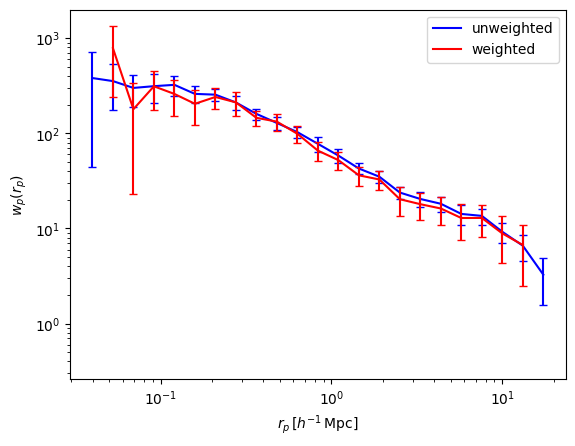

In [48]:
res1.plot(color='b', label='unweighted', mask_nonpositive=True)
res2.plot(color='r', label='weighted', mask_nonpositive=True)
plt.legend();

## Compare counts with original code

In [44]:
# Read Claudio reference sample for crosscorr
cd0 = Table.read('/home/edonoso/proj/wrprefac_test/claudiosample/claupccf.cd', format='ascii')
selected_columns = ['cd']
column_data = [cd0[col].data for col in selected_columns]
cd0 = np.array(column_data).T
cr0 = Table.read('/home/edonoso/proj/wrprefac_test/claudiosample/claupccf.cr', format='ascii')
selected_columns = ['cr']
column_data = [cr0[col].data for col in selected_columns]
cr0 = np.array(column_data).T
wrp0 = Table.read('/home/edonoso/proj/wrprefac_test/claudiosample/claupccf.wrp', format='ascii')
wrp0 = wrp0['wrp'].data

In [45]:
cd0 - res1.counts.d1d2

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [46]:
cr0 - res1.counts.d1r2

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [47]:
wrp0 - res1.wp

array([-3.07692301e-06,  2.17391306e-06,  2.09302334e-06,  2.81690143e-06,
       -1.62162155e-06,  1.04477613e-06, -1.36986330e-07,  4.96782496e-06,
        1.00303944e-06,  3.80887062e-06,  1.58798284e-06, -3.58974364e-06,
       -2.18611018e-06, -1.76034844e-06,  1.17221424e-06, -4.36608177e-06,
        3.51259159e-06, -2.03520250e-06,  1.80403330e-06, -3.52986807e-06,
        2.35959308e-06, -1.80738905e-06,  3.79141984e-06, -1.72583399e-06,
       -1.40582524e-06,  1.72080477e-06,  4.68671593e-06, -3.90269744e-06])